# import and functions

In [3]:
import sys
sys.path.append("../src")
import numpy
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from data_loader import load_data
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
parent_dir = Path("../data/ml-latest-small")

movies, ratings = load_data(parent_dir)
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [ ]:
reader = Reader(rating_scale=(0.5, 5))

data = Dataset.load_from_df(
    ratings[["userId", "movieId", "rating"]],
    reader
)

In [41]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [42]:
def basic_info(movies, ratings):
    print("Number of users:", ratings["userId"].nunique())
    print("Number of movies:", movies["movieId"].nunique())
    print("Number of ratings:", len(ratings))

basic_info(movies, ratings)

Number of users: 610
Number of movies: 9742
Number of ratings: 100836


In [43]:
print(ratings.head() )
print(ratings.describe())

   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931
              userId        movieId         rating     timestamp
count  100836.000000  100836.000000  100836.000000  1.008360e+05
mean      326.127564   19435.295718       3.501557  1.205946e+09
std       182.618491   35530.987199       1.042529  2.162610e+08
min         1.000000       1.000000       0.500000  8.281246e+08
25%       177.000000    1199.000000       3.000000  1.019124e+09
50%       325.000000    2991.000000       3.500000  1.186087e+09
75%       477.000000    8122.000000       4.000000  1.435994e+09
max       610.000000  193609.000000       5.000000  1.537799e+09


In [44]:
print(movies.head() )
print(movies.describe())

   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  
             movieId
count    9742.000000
mean    42200.353623
std     52160.494854
min         1.000000
25%      3248.250000
50%      7300.000000
75%     76232.000000
max    193609.000000


## Rating Distribution

In [45]:
ratings["rating"].value_counts().sort_index()

rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211
Name: count, dtype: int64

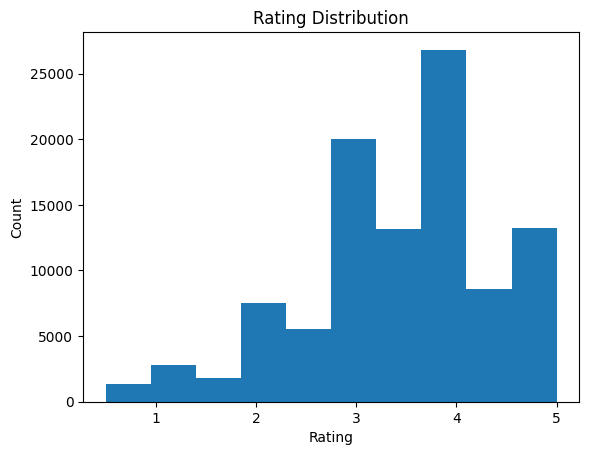

In [77]:
def rating_distribution(ratings):
    plt.hist(ratings["rating"], bins=10)
    plt.title("Rating Distribution")
    plt.xlabel("Rating")
    plt.ylabel("Count")
    plt.show()

rating_distribution(ratings)

## Top Active Users

In [46]:
user_counts = ratings["userId"].value_counts()

user_counts.head()

userId
414    2698
599    2478
474    2108
448    1864
274    1346
Name: count, dtype: int64

In [47]:
data = pd.merge(ratings, movies, on="movieId")

data.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [48]:
data.groupby("title")["rating"].mean().sort_values(ascending=False).head(10)

title
Karlson Returns (1970)                                                         5.0
Zeitgeist: Moving Forward (2011)                                               5.0
Dream of Light (a.k.a. Quince Tree Sun, The) (Sol del membrillo, El) (1992)    5.0
Dragons: Gift of the Night Fury (2011)                                         5.0
12 Angry Men (1997)                                                            5.0
Justice League: Doom (2012)                                                    5.0
Junior and Karlson (1968)                                                      5.0
Jump In! (2007)                                                                5.0
Human Condition III, The (Ningen no joken III) (1961)                          5.0
Louis Theroux: Law & Disorder (2008)                                           5.0
Name: rating, dtype: float64

In [49]:
def most_rated_movies(ratings, movies):
    movie_counts = ratings["movieId"].value_counts().head(10)
    
    top_movies = movies[movies["movieId"].isin(movie_counts.index)]
    
    print("\nTop 10 most rated movies:")
    print(top_movies[["title"]])

most_rated_movies(ratings, movies)


Top 10 most rated movies:
                                          title
97                            Braveheart (1995)
224   Star Wars: Episode IV - A New Hope (1977)
257                         Pulp Fiction (1994)
277            Shawshank Redemption, The (1994)
314                         Forrest Gump (1994)
418                        Jurassic Park (1993)
461                     Schindler's List (1993)
507           Terminator 2: Judgment Day (1991)
510            Silence of the Lambs, The (1991)
1939                         Matrix, The (1999)


In [76]:
user_movie_matrix = ratings.pivot_table(
    index="userId",
    columns="movieId",
    values="rating"
)
user_movie_matrix = user_movie_matrix.fillna(0)
user_movie_matrix.shape

(610, 9724)

📐 Formula intuition

similarity(A,B)=
∥A∥∥B∥
A⋅B
	​


In [55]:
similarity = cosine_similarity(user_movie_matrix.T)  # item-item similarity

similarity.shape

(9724, 9724)

In [63]:
movie1 = user_movie_matrix[1]
movie2 = user_movie_matrix[2]

In [64]:
cosine_similarity([movie1], [movie2])

array([[0.41056206]])

In [65]:
user_movie_matrix_norm = user_movie_matrix.subtract(
    user_movie_matrix.mean(axis=1),
    axis=0
)